In [1]:
import numpy as np
import matplotlib.pyplot as plt
# import scipy.linalg as scl
%matplotlib notebook
%pylab


a=1.5
b=5.5
Nx=120 # The Maximum Nx here is 129 after no cure no waefunction


#########################IMPORTNANT #############################

#If you want to go more than 100 (Or you want to encrease your sample size,) you should inrease your ending number
#for example in this case b=4 then max N=129 but if b=more than 4 then Max N=more than 100.
#Example 2: b=13 and N=500, Mais sa ne sert a rien d'augmenter le sample size N dans ce cas car sa conduit a augmenter le z-cordinate et en plus notre intervalle est restreint du a la restriction provenant du wavefunction.
# Just take b=4 N=100
#TU CNNAIS POURQUOI TU NE PEUX ALLER PLUS LOI DE b=4, because of my measurement I took a values of the z-coordinates between 1- 3 for the 1D PES and than, it is useless to take b=more than 4 because I will get 0 for the wavefunction after b=3 or 4.




#dx=((b-a)/Nx)
x=np.linspace(a,b,Nx-2)
dx=x[1]-x[0]
#dx = 0.025 #  If you considered this one, you are going to have good value for the Energies near to the analytical parceque le vrai dx c'est ceci 0.02400000000000002
H=dx**2
#compute the second derirative and add minus
A=np.zeros((Nx-2,Nx-2))
for i in range(Nx-2):
    for j in range(Nx-2):
        if i==j:
            A[i,j]=-2
        elif i==j+1:
            A[i,j]=1
        elif i+1==j:
            A[i,j]=1
            
            

############### NEW PARAMETEERS ########################
m=3.39e11# in kj.mol-1.c^-2 For 4He
#m=2.59e11# in kj.mol-1.c^-2 For 3He
h_bar=1.9e5 #in KJ.A.mol-1.c-2

##############################CCSD(T)/Aug-cc-pVTZ obtained in Cfour ########################################
alpha=2.04# in 1/A
De=8.17 #in Kj/mol
re=2.01#in A
#h_bar=1.9e5 #in KJ.A.mol-1.c-2
  

##############  Construct the Potential ###############
T=-(((h_bar)**2)/(2*m*H))*A

#T=-((((h_bar)**2)*(alpha)**2)/(2*m*H))*A

# T=-((((h_bar)**2)*(alphaa)**2)/(2*m))*A

# AA
# De*(-2*np.e xp(-alphaa*(x-xe))+np.exp(-2*alphaa*(x-xe)))
K = 1 
#rr=np.linspace(-4,b,Nx-2)
r=np.linspace(a,b,Nx-2)
z1=(r-re)
def V(r):
    #return De*(np.exp(-2*alpha*z1)-2*np.exp(-alpha*z1))+ De
    return De*(1-np.exp(-alpha*z1))**2 -De


B=V(r)@(np.identity(Nx-2))
VV=np.diag(V(r)) 

Using matplotlib backend: nbAgg
Populating the interactive namespace from numpy and matplotlib


<IPython.core.display.Javascript object>


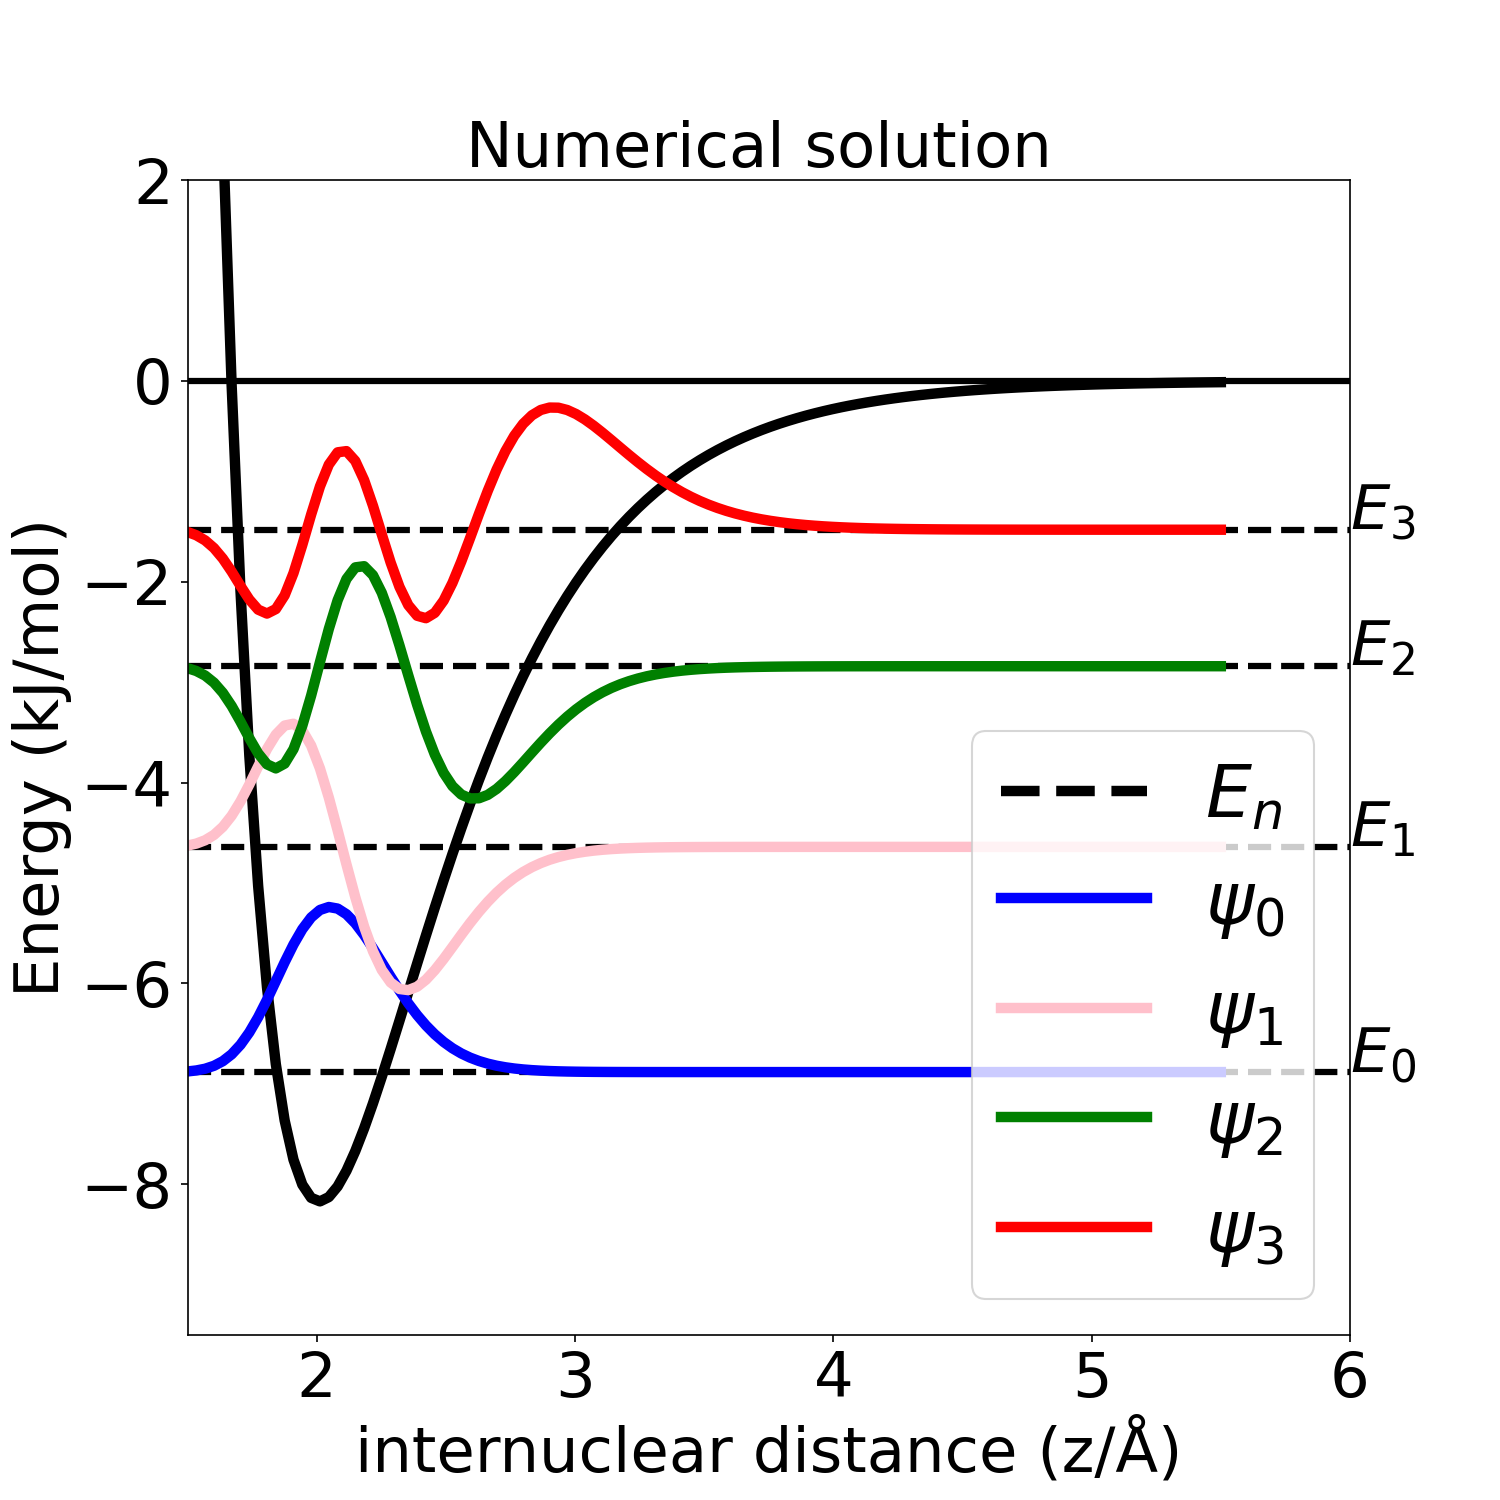

In [40]:

# print(Hami)
Hami=(T+VV)
np.linalg.det(Hami)
eigenvalues, eigenvectors = np.linalg.eig(Hami)
E=eigenvalues
W=eigenvectors.T  #we use T as a transpose here which is a kind of normalization in analytical resolution


# Amst=1e-10
# # re=2*Amst
# rr=np.linspace(0.5*Amst,10*Amst,98)

fig, ax = plt.subplots(figsize=(10,10))
ax.plot(x,B, color='black', lw=5)
plt.axhline(y=0,  color ='black',lw=3)
#rr=np.linspace(a,b,Nx-2) # you will end at 97


for n in range(4): 
    #plt.plot(x,((W[n])/(np.sqrt(np.sum(np.abs(W[n])**2, axis=0)*dx)))+E[n], lw=5)
    plt.axhline(E[n], color='black', linestyle='--', lw=3) 
    plt.text(6, E[n], f"$E_{n}$",fontsize=30)
    plt.title('Numerical solution ',fontsize=30)
    #plt.text(4, E[n], f"$n={n}$")
    
#for n in range(3): 
plt.axhline(E[n]-De, color='black', linestyle='--', label= "$E_{n}$",lw=5)
plt.plot(x,((W[0])/(np.sqrt(np.sum(np.abs(W[0])**2, axis=0)*dx)))+(E[0]), color='b', label= '$\psi_{0}$', lw=5)
plt.plot(x,((W[1])/(np.sqrt(np.sum(np.abs(W[1])**2, axis=0)*dx)))+(E[1]), color='pink', label= '$\psi_{1}$',lw=5)
plt.plot(x,((W[2])/(np.sqrt(np.sum(np.abs(W[2])**2, axis=0)*dx)))+(E[2]), color='green', label= '$\psi_{2}$', lw=5)
plt.plot(x,((W[3])/(np.sqrt(np.sum(np.abs(W[3])**2, axis=0)*dx)))+(E[3]), color='r', label= '$\psi_{3}$', lw=5)
    #plt.axhline(E[n], color='black', linestyle='--', lw=2) 
   # plt.text(4, E[n], f"$E_{n}$",fontsize=30)
    #plt.text(4, E[n], f"$n={n}$")
    

#     plt.plot(rr,W[n]+E[n], lw=2)
#     plt.axhline(E[n], color='black', linestyle='--') 
#     plt.text(4, E[n], f"$n={n}$")

#plt.title('Numerical solution',fontsize=30) 
plt.tick_params(labelsize=30)
plt.xlabel('internuclear distance (z/Å)', fontsize=30)
ax.set_ylabel('Energy (kJ/mol)',fontsize=30)
plt.xlim(1.5, 6)
plt.ylim(-9.5, 2)
plt.legend(loc = 0)
plt.legend(prop={'size':35})
plt.show()


In [27]:
print('-----------------Table of Values (States Index VS Energies)-------------')
print("{:8d} {:24.4f} ".format(0,E[0]))
print("{:8d} {:24.4f} ".format(1,E[1]))
print("{:8d} {:24.4f} ".format(2,E[2]))
print("{:8d} {:24.4f} ".format(3,E[3]))
print("{:8d} {:24.4f} ".format(4,E[4]))
print("{:8d} {:24.4f} ".format(5,E[5]))
print("{:8d} {:24.4f} ".format(6,E[6]))
print("{:8d} {:24.4f} ".format(7,E[7]))
print("{:8d} {:24.4f} ".format(8,E[8]))
print("{:8d} {:24.4f} ".format(9,E[9]))
print("{:8d} {:24.4f} ".format(10,E[10]))

-----------------Table of Values (States Index VS Energies)-------------
       0                  -6.8821 
       1                  -4.6399 
       2                  -2.8412 
       3                  -1.4821 
       4                  -0.5609 
       5                  -0.0698 
       6                   0.2062 
       7                   0.5810 
       8                   1.0579 
       9                   1.6218 
      10                   2.2643 


In [28]:
import functools
import time
def timer(func):

    @functools.wraps(func)
    def wrapper(*args, **kwargs):
        start_time = time.perf_counter()
        value = func(*args, **kwargs)
        end_time = time.perf_counter()
        run_time = end_time - start_time
        print("Finished {} in {} secs".format(repr(func.__name__), round(run_time, 3)))
        return value

    return wrapper


In [16]:
# Wavenumbers
Const=hc=0.33#in Kj/mol
w=E/Const  #in cm
w

array([-2.08548336e+01, -1.40604373e+01, -8.60968705e+00, -4.49113666e+00,
       -1.69983910e+00, -2.11380821e-01,  6.24896840e-01,  1.76055574e+00,
        3.20563449e+00,  4.91446481e+00,  6.86151845e+00,  9.02970963e+00,
        1.14064678e+01,  1.39819623e+01,  1.67481726e+01,  1.96983556e+01,
        2.28267197e+01,  2.61282161e+01,  2.95983957e+01,  3.32333052e+01,
        3.70294014e+01,  4.09834753e+01,  4.50925786e+01,  4.93539504e+01,
        5.37649462e+01,  5.83229697e+01,  6.30254126e+01,  6.78696033e+01,
        7.28527678e+01,  7.79720014e+01,  8.32242520e+01,  8.86063119e+01,
        9.41148170e+01,  9.97462509e+01,  1.05496953e+02,  1.11363125e+02,
        1.17340847e+02,  1.23426078e+02,  1.29614675e+02,  1.35902393e+02,
        1.42284902e+02,  1.48757786e+02,  1.55316554e+02,  1.61956645e+02,
        1.68673435e+02,  1.75462238e+02,  1.82318316e+02,  1.89236877e+02,
        1.96213088e+02,  2.03242068e+02,  2.10318904e+02,  2.17438643e+02,
        2.24596304e+02,  

In [17]:
# Energies
# EE=((h_bar)**2/2*m)*E
# EE

print('-----------------Table of Values (States Index VS Energies)-------------')
print("{:8d} {:24.4f} ".format(0,E[0]))
print("{:8d} {:24.4f} ".format(1,E[1]))
print("{:8d} {:24.4f} ".format(2,E[2]))
print("{:8d} {:24.16f} ".format(3,E[3]))

-----------------Table of Values (States Index VS Energies)-------------
       0                  -6.8821 
       1                  -4.6399 
       2                  -2.8412 
       3      -1.4820750982927857 
